# Lab 10: Advanced Network Topics

This lab expands beyond the standard network analysis tools to cover frontier topics. These topics are offered as exposition only and will not cover the intricacies associated to each of the extensions. In particular, in this lab we cover:
1. A review of static, single-layer, dyadic networks
2. Dynamic networks
3. Multiplex networks
4. Multilayer networks
5. Hypergraphs and Bipartite Representations
6. Application: Neural Networks
7. Application: Causality Graphs and Directed Acyclical Graphs (DAGs)

In [64]:
# Setup
import igraph as ig
import numpy as np
import matplotlib.pyplot as plt
import random

# Set random seed for reproducibility
seed_value = 123456789
rng = np.random.default_rng(seed_value)
random.seed(seed_value)

# Visualization function for graphs
def plot_graph(g, ax=None, layout="fr", title=None, show=True, labels=None, colors=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))
    ig.plot(
        g,
        target=ax,
        layout=layout,
        vertex_size=25,
        vertex_color="indianred" if colors is None else colors,
        vertex_label=list(range(g.vcount())) if labels is None else labels,
        edge_width=1.5,
        edge_arrow_size=5,
        bbox=(400,400),
        margin=30
    )
    if title is not None:
        ax.set_title(title)
    if show:
        plt.show()

## 1. Review

Until now, we have discussed only a specific kind of graphs $\mathcal{G} = (\mathcal{N}, \mathcal{E})$ composed of nodes $\mathcal{N}$ and edges $\mathcal{E}$. All graphs we have discussed so far assume:
1. Static environment: nodes $\mathcal{N}$ and edges $\mathcal{E}$ do not change
2. Single layer of connections: $\mathcal{G}$ captures a single dimension of connections (e.g., whether friends or co-workers, not both)
3. Dyadic links: edges $\mathcal{E}$ only involve two nodes at a time (not three or more)

We could allow for binary connections, weighted graphs, directed edges and even self-loops, but previous properties remained fixed. We first provide a review of these kind of networks for completeness. The network considered is randomly drawn as an illustrative example.

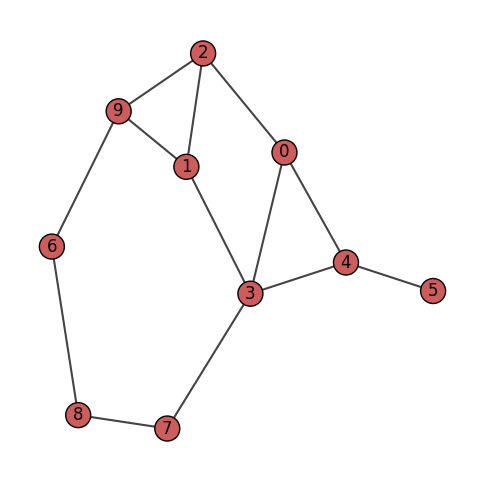

Example static Graph properties:
Number of nodes: 10
Number of edges: 13
Density: 0.2888888888888889
Clustering: 0.25
Degree sequence: [3, 3, 3, 4, 3, 1, 2, 2, 2, 3]
Most central node (degree): 3
Most central node (eigenvector): 3


In [65]:
# Generate a random graph and visualize
g = ig.Graph.Erdos_Renyi(n=10, p=0.3)
plot_graph(g)

# Once generated, nodes and edges remain fixed
# We can then analyze this fixed graph's properties
print("Example static Graph properties:")
print("Number of nodes:", g.vcount())
print("Number of edges:", g.ecount())
print("Density:", g.density())
print("Clustering:", g.transitivity_undirected())

# Centrality
degree_sequence = g.degree()
eigen_centrality = g.eigenvector_centrality()
print("Degree sequence:", degree_sequence)
print("Most central node (degree):", np.argmax(degree_sequence))
print("Most central node (eigenvector):", np.argmax(eigen_centrality))

## 2. Dynamic Networks

We first remove Property 1, taking away the static environment and allowing for a dynamic environment. This uses the fact that dynamics (time) have a clear ordering, denoted as: $t = 1, 2, 3, \ldots, T$. That is, $t=1$ is the first observed period, $t=2$ marks the second period, and so on, until the last period $t = T$. Time intervals do not need to be evenly spaced. With a time order, one can allow for $\mathcal{N}_t$ and $\mathcal{E}_t$, nodes and edges, respectively, which change with time $t$.

Following example uses $T = 3$ time periods, with changing nodes and edges.

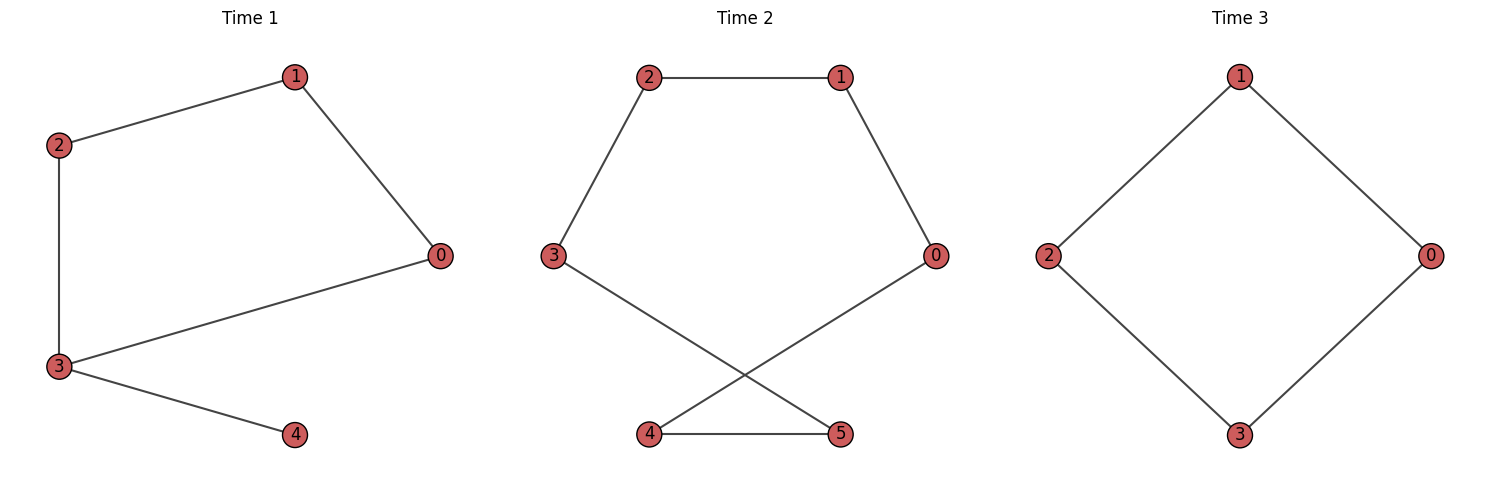

Densities over time: [0.5, 0.4, 0.6666666666666666]
Avg degree over time: [np.float64(2.0), np.float64(2.0), np.float64(2.0)]


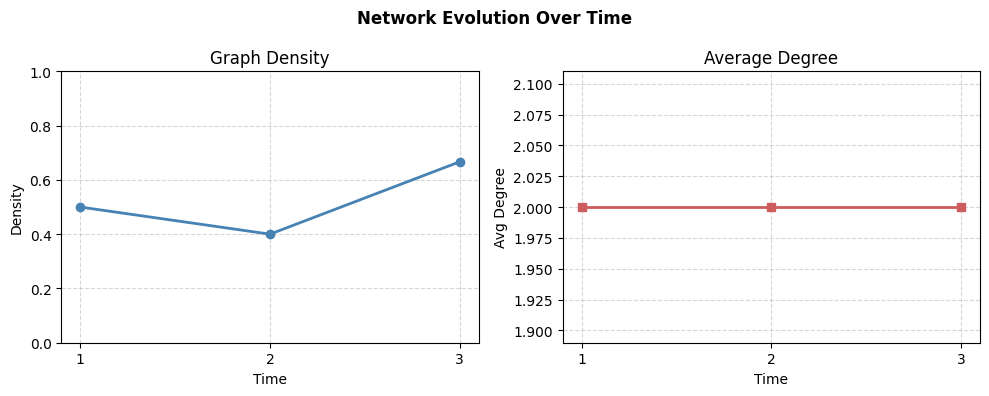

In [66]:
# Temporal Networks: 3 time snapshots with changing nodes and edges
# Time 1: 5 nodes (0-4), baseline connections
g1 = ig.Graph(n=5, directed=False)
g1.add_edges([(0,1),(1,2),(2,3),(3,4),(0,3)])

# Time 2: Node 5 is ADDED; edges rewired to include it
g2 = ig.Graph(n=6, directed=False)
g2.add_edges([(0,1),(1,2),(2,3),(3,5),(4,5),(0,4)])   # node 5 joins, (3,4) and (0,3) drop

# Time 3: Nodes 1 and 3 are REMOVED (relabelled: 0→0, 2→1, 4→2, 5→3)
g3 = ig.Graph(n=4, directed=False)
g3.add_edges([(0,1),(1,2),(2,3),(0,3)])                # tighter ring among survivors
graphs = [g1, g2, g3]
times = [1, 2, 3]

# Visualize each time snapshot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, graph in enumerate(graphs):
    plot_graph(graph, ax=axes[i], layout="circular", title=f"Time {times[i]}", show=False)
plt.tight_layout()
plt.show()

# Track statistics over time
densities = [g.density() for g in graphs]
avg_deg = [np.mean(g.degree()) for g in graphs]
print("Densities over time:", densities)
print("Avg degree over time:", avg_deg)

# Plotting the evolution of density and average degree
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Network Evolution Over Time", fontweight="bold")

ax1.plot(times, densities, marker='o', color="steelblue", linewidth=2)
ax1.set_title("Graph Density")
ax1.set_xlabel("Time")
ax1.set_ylabel("Density")
ax1.set_xticks(times)
ax1.set_ylim(0, 1)          # density is always in [0,1] — fix the axis
ax1.grid(True, linestyle="--", alpha=0.5)

ax2.plot(times, avg_deg, marker='s', color="indianred", linewidth=2)
ax2.set_title("Average Degree")
ax2.set_xlabel("Time")
ax2.set_ylabel("Avg Degree")
ax2.set_xticks(times)
ax2.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## 3. Multiplex Networks

We now remove the Property 2, allowing for more than a single layer of connections between nodes. Specifically, **multiplex networks** allow for the same nodes $\mathcal{N}$ to be connected across multiple $L$ layers of edges $\mathcal{E}_1, \ldots, \mathcal{E}_L$ (and connections are only allowed within each layer).

In the example below, we consider a set of $n$ nodes $\mathcal{N}$ that can be connected in three ways ($L = 3$): any two nodes can have friendship links ($\mathcal{E}_1$), a collaborative relationship (i.e., working together or investing in the same business; $\mathcal{E}_2$), or be neighbours ($\mathcal{E}_3$). Two individuals can have links in each layer, but no connections are allowed across layers (e.g., a node $i$ in the friendship layer cannot be connected to another node $j$ in the collaboration layer).

As `igraph` does not support multilayer networks, we invoke an additional set of tools from the `pymnet` module.

In [67]:
# Install and import pymnet for multilayer network analysis (uncomment the line below if you haven't installed it yet)
# %pip install pymnet
import pymnet

{'Collaboration': {np.int64(0): 2, np.int64(1): 3, np.int64(2): 0, np.int64(3): 5, np.int64(4): 2, np.int64(5): 1, np.int64(6): 2, np.int64(7): 3, np.int64(8): 0, np.int64(9): 0}, 'Friendship': {np.int64(0): 1, np.int64(1): 6, np.int64(2): 2, np.int64(3): 2, np.int64(4): 2, np.int64(5): 6, np.int64(6): 1, np.int64(7): 1, np.int64(8): 2, np.int64(9): 3}, 'Neighbourship': {np.int64(0): 3, np.int64(1): 4, np.int64(2): 2, np.int64(3): 4, np.int64(4): 4, np.int64(5): 4, np.int64(6): 2, np.int64(7): 5, np.int64(8): 8, np.int64(9): 4}}
{'Friendship': np.float64(2.6), 'Collaboration': np.float64(1.8), 'Neighbourship': np.float64(4.0)}
Layer: 'Friendship', Density: 0.289, Avg Degree: 2.60
Layer: 'Collaboration', Density: 0.200, Avg Degree: 1.80
Layer: 'Neighbourship', Density: 0.444, Avg Degree: 4.00


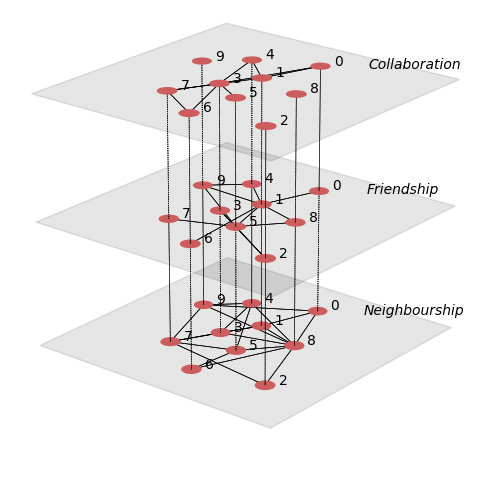

In [68]:
# Custom function for creating an Erdos-Renyi multiplex network with layer names
def er_multiplex_layers(n, p, layers, categorical=False, rng=None):
    # Generator for reproducibility and pre-allocation
    if rng is None:
        rng = np.random.default_rng(seed_value)
    couplings = "categorical" if categorical else None
    multiplex_graph = pymnet.MultiplexNetwork(couplings=couplings)

    # Loop over layers, create ER graph for each
    for index, layer in enumerate(layers):
        multiplex_graph.add_layer(layer) # Add layer to multiplex graph
        
        # Create upper triangle indices for undirected graph (no self-loops)
        utri = np.triu_indices(n, k = 1)
        max_changes = int(n * (n - 1) / 2)
        links = (rng.random(max_changes) < p[index])

        # Loop over non-zero indices to set adjacency directly in multiplex graph
        for i, j in zip(utri[0][links], utri[1][links]):
            multiplex_graph.A[layer][i, j] = 1
    return multiplex_graph

# Create layers of a multiplex network (same nodes, different edges)
n = 10
categorical = True  # Draw edges across layers for same nodes?
layers = ["Friendship", "Collaboration", "Neighbourship"]
p = [0.3, 0.2, 0.4]
multiplex_graph = er_multiplex_layers(n, p, layers, categorical=categorical, rng=rng)
print(multiplex_graph)

# Print density and average degree per layer
densities = pymnet.multiplex_density(multiplex_graph)
degrees = pymnet.multiplex_degs(multiplex_graph, degstype='nodes')
print(degrees)
avg_degrees = {layer: np.mean(list(degrees[layer].values())) for layer in layers}
print(avg_degrees)
for layer in layers:
    print(f"Layer: '{layer}', Density: {densities[layer]:.3f}, Avg Degree: {avg_degrees[layer]:.2f}")

# Visualize multiplex network using pymnet
pymnet.draw(
    multiplex_graph,
    defaultNodeColor="indianred",
    defaultEdgeColor="black",
    defaultNodeSize=20,
    defaultEdgeWidth=0.5,
    defaultLayerColor="black",
    defaultLayerAlpha=0.1,
    defaultLayerLabelStyle="oblique",
    layergap=1.2,
    layerPadding=0.5,
    defaultLayerLabelLoc=(0.7,0.9),
    autoscale=False,
    figsize=(8, 6)
)
plt.show()

## 4. Multilayer Networks

Multiplex networks allow for multiple layers, but nodes must remain the same across all layers and no connections are allowed between layers. While a formal definition is outside the scope of the course, we can say **multilayer networks** lift those restrictions, allowing for the most general types of connections: nodes can be different in each layer and edges can exist both within and between layers. The definition of a multilayer network also allows for **aspects**: a grouping of layers capturing a common theme for connections. As an example, a firm's operational networks can have both **competitive** aspects (involving relationships to competitors and input providers) and **cooperative** aspects (involving relationships to other firms and their customers).

In the example below, we consider a network where nodes are students in a school and consider the simplest case where there is only one aspect to the network (social relationships). In the example, we consider students sorted in different classes who can form study groups with other classmates, meet each other during recess and live in the same neighbourhood. This creates nodes sorted into three distinct layers (study, friendship and neighbourhood), where connections are allowed across layers (students in different classes can be friends and live close to each other).

[0, 1, 2, 3, 4, 5, 6, 7]
[8, 9, 10, 11, 12]
[13, 14, 15, 16, 17]
Layers: {'Class C', 'Class A', 'Class B'}
Nodes: [(13, 'Class C'), (14, 'Class C'), (15, 'Class C'), (16, 'Class C'), (17, 'Class C'), (0, 'Class A'), (1, 'Class A'), (2, 'Class A'), (3, 'Class A'), (4, 'Class A'), (5, 'Class A'), (6, 'Class A'), (7, 'Class A'), (8, 'Class B'), (9, 'Class B'), (10, 'Class B'), (11, 'Class B'), (12, 'Class B')]
All edges: [(0, 1, 'Class A', 'Class A', 1), (0, 2, 'Class A', 'Class A', 1), (0, 3, 'Class A', 'Class A', 1), (0, 4, 'Class A', 'Class A', 1), (0, 11, 'Class A', 'Class B', 2), (1, 2, 'Class A', 'Class A', 1), (1, 8, 'Class A', 'Class B', 1), (2, 8, 'Class A', 'Class B', 1), (3, 5, 'Class A', 'Class A', 1), (3, 13, 'Class A', 'Class C', 1), (3, 17, 'Class A', 'Class C', 2), (4, 12, 'Class A', 'Class B', 1), (5, 15, 'Class A', 'Class C', 1), (5, 13, 'Class A', 'Class C', 2), (5, 12, 'Class A', 'Class B', 2), (6, 7, 'Class A', 'Class A', 1), (8, 9, 'Class B', 'Class B', 1), (8, 11, '

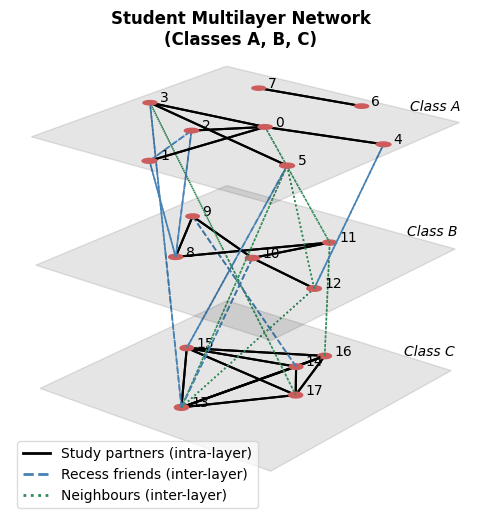

In [69]:
# Create layers of a multilayer network (different nodes per layer and edges across layers)
multilayer_network = pymnet.MultilayerNetwork(aspects=1, fullyInterconnected=False)
edge_color = {}
edge_style = {}
edge_width = {}

# Add nodes and layers to the multilayer network
nodes = range(18)  # 18 unique students across all classes
class_assignment = {
    "Class A": range(0, 8),   # Students 0-7
    "Class B": range(8, 13),  # Students 8-12
    "Class C": range(13, 18)  # Students 13-17
}
for layer, node_range in class_assignment.items():
    multilayer_network.add_layer(layer)
    print(list(node_range))
    for node in node_range:
        multilayer_network.add_node(node, layer)

# Intra-layer edges: study partners
study_partners = {
    "Class A": [(0,1),(1,2),(0,2),(0,3),(0,4),(3,5),(6,7)],
    "Class B": [(8,9),(9,10),(10,11),(8,11),(8,11),(10,12)],
    "Class C": [(13,14),(13,15),(13,16),(13,17),(14,15),(14,16),(14,17),(15,16),(15,17),(16,17)]
}
for layer, edges in study_partners.items():
    for u, v in edges:
        multilayer_network[u, v, layer, layer] = 1
        key = ((u, layer), (v, layer))
        edge_color[key] = "black"
        edge_style[key] = "-"
        edge_width[key] = 1.5

# Inter-layer edges: recess friends
recess_friends = [
    (1, "Class A", 2,  "Class A"),
    (1, "Class A", 8,  "Class B"),
    (2, "Class A", 8,  "Class B"),
    (4, "Class A", 12, "Class B"),
    (9, "Class B", 14, "Class C"),
    (5, "Class A", 15, "Class C"),
    (10, "Class B", 13, "Class C"),
    (3, "Class A", 13,  "Class C"),
]
for u, lu, v, lv in recess_friends:
    multilayer_network[u, v, lu, lv] = 1
    key = ((u, lu), (v, lv))
    edge_color[key] = "steelblue"
    edge_style[key] = "--"
    edge_width[key] = 1.2

# Inter-layer edges: live on same neighbourhood
neighbours = [
    (0, "Class A", 11,  "Class B"),
    (11, "Class B", 16,  "Class C"),
    (3, "Class A", 17, "Class C"),
    (5, "Class A", 13, "Class C"),
    (5, "Class A", 12, "Class B"),
    (12, "Class B", 13, "Class C")
]
for u, lu, v, lv in neighbours:
    multilayer_network[u, v, lu, lv] = 2
    key = ((u, lu), (v, lv))
    edge_color[key] = "seagreen"
    edge_style[key] = ":"
    edge_width[key] = 1.2

# Print basic info about the multilayer network
print("Layers:", multilayer_network.get_layers())
print("Nodes:",  list(multilayer_network.iter_node_layers()))
print("All edges:", list(multilayer_network.edges)) # Format: (u, v, layer_u, layer_v, aspect)

# Visualize multilayer network using pymnet
fig, ax = plt.subplots(figsize=(8, 6), subplot_kw=dict(projection="3d"))
pymnet.draw(
    multilayer_network,
    ax=ax,
    layout="fr",
    defaultNodeColor="indianred",
    defaultNodeSize=20,
    defaultLayerColor="black",
    defaultLayerAlpha=0.1,
    edgeColorDict=edge_color,
    edgeStyleDict=edge_style,
    edgeWidthDict=edge_width,
    layergap=1.2,
    defaultLayerLabelStyle="oblique",
    defaultLayerLabelLoc=(0.8,1.0),
    autoscale=False
)

# Add a manual legend for edge types
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], color="black", lw=2, ls="-",  label="Study partners (intra-layer)"),
    Line2D([0],[0], color="steelblue",  lw=2, ls="--", label="Recess friends (inter-layer)"),
    Line2D([0],[0], color="seagreen", lw=2, ls=":",  label="Neighbours (inter-layer)"),
]
ax.legend(handles=legend_elements, loc="lower left", framealpha=0.7)
plt.title("Student Multilayer Network\n(Classes A, B, C)", fontweight="bold")
plt.show()

## 5. Hypergraphs and Bipartite Representations

### Definition

Finally, we remove Property 3, allowing for edges that form between more than two nodes in a graph. This leads us to the concepts of **hyperedges** and **hypergraphs** between nodes $\mathcal{N}$. A **directed hyperedge** $E$ is a pair of **node subsets**, so that $E = (D, C)$ with $D \subset \mathcal{N}$ and $C \subset \mathcal{N}$ means nodes in $D$ are connected to nodes in $C$. When hyperedges are **undirected**, we let $E$ be a single node subset of $\mathcal{N}$ representing all nodes joined by this edge. A **hypergraph** $\mathfrak{G} = (\mathcal{N}, \mathfrak{E})$ is therefore the set of nodes along with all (directed or undirected) hyperedges $E \in \mathfrak{E}$.

Compare the definition of hypergraphs to the standard definition of a graph. An **directed edge** $e$ is defined as a pair of **nodes**, so that $e = (d, c)$ with $d \in \mathcal{N}$ and $c \in \mathcal{N}$ means $d$ is connected to $c$. When edges are **undirected**, we let $e = \{d, c\} = \{c, d\}$ be a subset of $\mathcal{N}$ representing the two nodes joined by this edge. A (dyadic) graph $\mathcal{G} = (\mathcal{N}, \mathcal{E})$ is therefore the set of nodes along with all (directed or undirected) edges $e \in \mathcal{E}$. The main difference is that **hyperedges** can contain an **arbitrary number of nodes**, whereas **edges** can only contain **exactly two nodes**.

We will consider the same in-class example, where there are $n=7$ nodes so that $\mathcal{N}_7 = \{v_1, \ldots, v_7\}$ and we consider the hyperedges:
- $E_1 = \{1, 2, 3\}$
- $E_2 = \{2, 3\}$
- $E_3 = \{3, 5, 6\}$
- $E_4 = \{4\}$

Together, $\mathcal{N}$ and $\mathfrak{E}_\text{example} = \{E_1, E_2, E_3, E_4\}$ compose our example hypergraph.

As `igraph` does not support multilayer networks, we invoke an additional set of tools from the `HyperNetX` module.

In [70]:
# Install and import pymnet for multilayer network analysis (uncomment the line below if you haven't installed it yet)
# %pip install hypernetx
import hypernetx as hnx
import pandas as pd

Nodes in hypergraph: [np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(6), np.int64(4), np.int64(7)]
Hyperedges in hypergraph: ['E1', 'E2', 'E3', 'E4', 'Isolated']


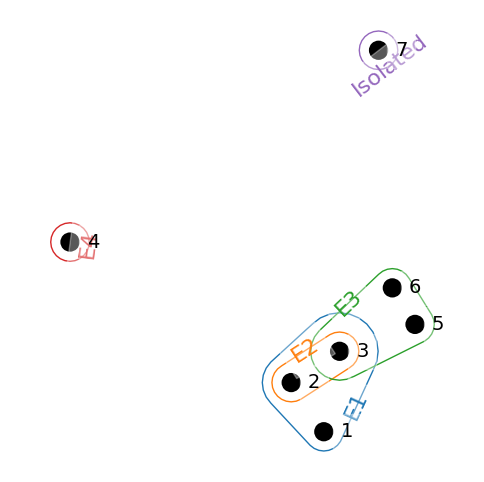

In [71]:
# Create a hypergraph and input hyperedges directly as incidence list format
rows = [
    (1, "E1"), (2, "E1"), (3, "E1"),  # Hyperedge E1 connects nodes 1, 2, 3
    (2, "E2"), (3, "E2"),             # Hyperedge E2 connects nodes 2, 3
    (3, "E3"), (5, "E3"), (6, "E3"),  # Hyperedge E3 connects nodes 3, 5, 6
    (4, "E4"),                        # Hyperedge E4 connects node 4
    (7, "Isolated")                   # Isolated node 7 with no hyperedges
]
df = pd.DataFrame(rows, columns=["node", "edge"])
H = hnx.Hypergraph(df, node_col="node", edge_col="edge")
print("Nodes in hypergraph:", list(H.nodes))
print("Hyperedges in hypergraph:", list(H.edges))
# print("Incidence matrix:\n", H.incidence_matrix())

# Visualize the hypergraph using HyperNetX's built-in drawing function
fig, ax = plt.subplots(figsize=(6, 6))
hnx.draw(H, ax=ax, node_radius=2, node_labels_kwargs={"fontsize": 14}, edge_labels_kwargs={"fontsize": 16})
plt.show()

### Bipartite Representations

Hypergraphs seem like complicated objects, due to the nature of edges containing either a single node or more than two nodes, which is impossible to visualize using dyadic graphs. However, it turns out we can represent all information about hypergraphs using dyadic networks already explored, particularly bipartite networks. We focus on undirected hypergraphs to make arguments simpler.

To enconde all information of a hypergraph $\mathfrak{G} = (\mathcal{N}, \mathfrak{E})$, we follow the following steps:
1. Define two groups of distict nodes: $\mathcal{U}$ and $\mathcal{V}$.
2. We let $\mathcal{U} = \mathcal{N}$, the set of original vertices.
3. For $\mathcal{V}$ we create as many nodes as there are hyperedges, so that $|\mathcal{V}| = |\mathfrak{E}|$ (where $|\cdot|$ represents the cardinality or number of elements in a set).
4. Note that each hyperedge $E \in \mathfrak{E}$ creates a new vertex $v(E) \in \mathcal{V}$ and involves a fixed number of nodes denoted as $n(E) \coloneqq |E|$.
5. For each hyperedge $E$, we connect all nodes $\{i \in \mathcal{N} \mid i \in E\}$ to $v(E)$, creating $n(E)$ new bipartite edges between $\mathcal{U}$ and $\mathcal{V}$.

By the end of the process, we will have a bipartite graph between $\mathcal{U}$ and $\mathcal{V}$ that exactly reflects the connections in the hypergraph. To clarify the process, let us apply it to the example hypergraph:
- As there are seven nodes ($|\mathcal{N}_7| = 7$) and four hyperedges ($|\mathfrak{E}_\text{example}| = 4$), we let $\mathcal{U} = \{1, \ldots, 7\}$ and $\mathcal{V} = \{v(E_1), v(E_2), v(E_3), v(E_4)\}$.
- Consider first hyperedge $E_1$. It involves nodes 1, 2, and 3; we connect these nodes to $v(E_1)$, creating 3 new edges.
- Move to second hyperedge $E_2$. It involves nodes 2 and 3; we connect these nodes to $v(E_2)$, creating 2 new edges.
- Move to third hyperedge $E_3$. It involves nodes 3, 5, and 6; we connect these nodes to $v(E_3)$, creating 3 new edges.
- Move to final hyperedge $E_4$. It involves node 4; we connect this nodes to $v(E_4)$, creating 1 new edge.
- A total of 9 bipartite edges between $\mathcal{U}$ and $\mathcal{V}$ are created.

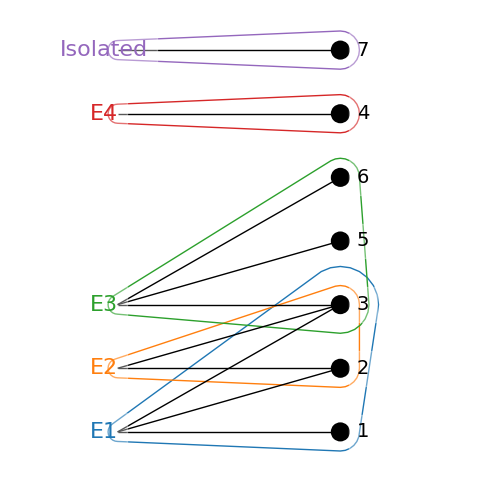

In [72]:
# Visualize bipartite (incidence) graph representation of the hypergraph
fig, ax = plt.subplots(figsize=(6, 6))
hnx.draw_bipartite_using_euler(H, ax=ax, node_radius=2, node_labels_kwargs={"fontsize": 14}, edge_labels_kwargs={"fontsize": 16})
plt.show()

## 6. Application: Neural Networks

Neural networks take advantage of graph properties in order to process information (inputs) and produce outputs. Many advanced neural network architertures exist, which use many of the networks we have discussed in the course: complete graphs, trees, lattices, multilayers, hypergraphs, etc. We focus on simple **feed-forward complete neural networks** for simplicity. These architectures take in $I$ inputs and produce a $O$ outputs, using $L$ hidden layers with $n$ nodes each, which are fully connected to adjacenct layers. The **feed-forward** nature means edges are directed from previous layers to the next, such that information flows from inputs to outputs.

These kind of neural network architectures are therefore fully defined by choosing $I$, $O$, $L$ and $n$. The total number of nodes in the network is $I + n \cdot L + O$ (inputs, outputs and all hidden nodes). To count the number of edges, note the input layer has $n \cdot I$ connections to the first hidden layer, the output layer has $n \cdot O$ connection to the last layer, and there are a total of $L - 1$ set of connections between hidden layers, each contributing $n^2$ edges. This means a total number of edges equal to $n \cdot I + n \cdot O + n^2 \cdot (L-1) = n \cdot [I + O + n \cdot (L- 1)]$.

As an example, you can have $I$ observations about individual wages in the entire labour market and you want to use this information to assign next year's wages for the $O$ employees at your company. You could train a neural network to perform this task. While training neural networks is outside the scope of the course, we provide code to visualize the above architecture for given values of $I$, $O$, $L$ and $n$.

In [73]:
import scipy.sparse as sp
def neural_network_graph(I, O, L, n):
    """
    Directed fully-connected feedforward neural network.
    Parameters
    ----------
    I (int): Number of input nodes.
    O (int): Number of output nodes.
    L (int): Number of hidden layers.
    n (int): Nodes per hidden layer.

    Returns
    -------
    A (scipy.sparse.csr_matrix): Sparse adjacency matrix.
    g (igraph.Graph): Directed graph.
    """
    # Define the size of each layer: input, hidden layers, output
    sizes = [I] + [n] * L + [O]  # List concatenation to create layer sizes
    K = len(sizes)
    n = sum(sizes)

    # Pre-allocate a KxK block matrix and fill the +1 block diagonal with blocks of ones
    blocks = np.full((K, K), None)                                             # None blocks interpreted as zero
    for k in range(K):
        m = sizes[k]
        blocks[k][k] = sp.csr_matrix((m, m), dtype=np.uint8)                   # Zero block on the diagonal
        if k < K - 1:
            p = sizes[k + 1]
            blocks[k][k + 1] = sp.csr_matrix(np.ones((m, p), dtype=np.uint8))  # Ones above main diagonal

    # Create full adjacency matrix from blocks using bmat (None is treated as zero block)
    A = sp.block_array(blocks, format="csr")
    rows, cols = A.nonzero()
    g = ig.Graph(
        n=sum(sizes),
        edges=list(zip(rows, cols)),
        directed=True
    )

    # Compute layout and colors for visualization (layered layout)
    formatting = {"layout": [], "vertex_color": [], "vertex_label": []}
    for layer, m in enumerate(sizes):
        if layer == 0:
            formatting['vertex_color'].extend(["lightgray"] * m)
            formatting['vertex_label'].extend([f"Input {i}" for i in range(m)])
        elif layer == K - 1:
            formatting['vertex_color'].extend(["lightblue"] * m)
            formatting['vertex_label'].extend([f"Output {i}" for i in range(m)])
        else:
            formatting['vertex_color'].extend(["salmon"] * m)
            formatting['vertex_label'].extend([f"Hidden {layer}.{i}" for i in range(m)])
        for j in range(m):
            x = layer
            y = m - j - (m - 1)/2
            formatting['layout'].append((x, y))
    return g, A, formatting

Total nodes in the neural network graph: 20
Total edges in the neural network graph: 84
Actual node count in the graph: 20
Actual edge count in the graph: 84
[[0 0 0 0 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0

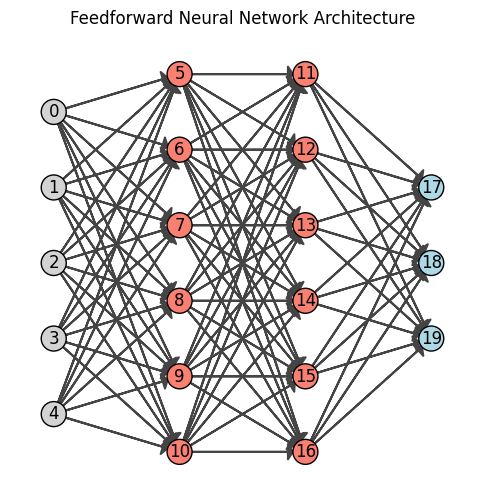

In [ ]:
# Set parameters of the neural network architecture
input_size = 5
output_size = 3
hidden_layers = 2
hidden_nodes_per_layer = 6

# Compute quantities for total nodes and edges in the feedforward architecture
total_nodes = input_size + hidden_layers * hidden_nodes_per_layer + output_size
total_edges = hidden_nodes_per_layer * (input_size + output_size + (hidden_layers - 1) * hidden_nodes_per_layer)
print(f"Total nodes in the neural network graph: {total_nodes}")
print(f"Total edges in the neural network graph: {total_edges}")

# Use igraph to construct a simple feedforward neural network architecture as a directed graph
neural_network_graph, A, formatting = neural_network_graph(
    input_size, output_size, hidden_layers, hidden_nodes_per_layer
)
print(f"Actual node count in the graph: {neural_network_graph.vcount()}")
print(f"Actual edge count in the graph: {neural_network_graph.ecount()}")
# print(A.todense())  # Print the adjacency matrix for verification

# Visualize neural network architecture (adding colors to layers)
plot_graph(neural_network_graph, title="Feedforward Neural Network Architecture",
           layout=formatting['layout'], colors=formatting['vertex_color'])

The complexity of a neural network is directly tied to its size, as this defines the scale and number of parameters the network can adjust to approximate a function. The most common parametrization of **feed-forward complete neural networks** is to assume one parameter per edge, plus a set of *bias parameters* for all but the input layer; an additional $n \cdot L + O$ parameters. This results in a total of $n \cdot [I + O + n \cdot (L- 1) + L] + O$ parameters.

In [75]:
# Total number of edges
total_edges = neural_network_graph.ecount()

# Total number of parameters
total_parameters = total_edges + hidden_nodes_per_layer * hidden_layers + output_size

print(f"Total edges in the neural network graph: {total_edges}")
print(f"Total parameters in the neural network: {total_parameters}")

Total edges in the neural network graph: 84
Total parameters in the neural network: 99


## 7. Causality Networks and Directed Acyclical Graphs (DAGs)

**Causality graphs** extend **directed** graphs $\mathcal{G} = (\mathcal{N}, \mathcal{E})$ by giving edges a structural interpretation: a directed edge $e = (i, j)$ means node $i$ is a **direct cause** of node $j$. When no directed cycles are present (i.e., it is impossible to start at a node and return to it by following directed edges), the graph is called a **Directed Acyclical Graph (DAG)**.

Formally, a DAG $\mathcal{D} = (\mathcal{N}, \mathcal{E})$ satisfies the **acyclicity constraint**: there is no sequence of nodes $i_1, i_2, \ldots, i_k$ such that $(i_1, i_2), (i_2, i_3), \ldots, (i_{k-1}, i_k), (i_k, i_1) \in \mathcal{E}$. This constraint ensures a well-defined **topological ordering** of nodes, meaning one can always label nodes $1, \ldots, n$ such that all edges point from lower to higher indices. Intuitively, this simply means *causes should occur before consequences*. DAGs are therefore a natural language for encoding causal assumptions in a system.

A key concept in DAGs is the distinction between **observed** and **unobserved** nodes. Observed nodes correspond to variables that are measured in the data, while unobserved nodes (also called **latent variables** or **confounders**) represent variables that influence the system but are not directly measurable. An unobserved node $U$ that causes both $X$ and $Y$ induces a **spurious correlation** between $X$ and $Y$: even if $X$ does not cause $Y$, the two will appear correlated in data because they share the common cause $U$. This is the central challenge of causal inference, and DAGs make such confounding structures explicit and transparent. DAGs allow one to express such causality assumptions as network properties (directedness, aciclicality, no back-door paths, etc.). This makes causal inference an issue of network discovery, with the field sometimes known as **causal graphical models** (or causal *discovery* models).

In the examples below, we consider two DAGs of increasing complexity. The first is a simple economic example involving education, wages and ability. The second is a more complex scientific example involving factors that determine surface temperature $T$.

DAG 1 — Is DAG: True
Topological order: ['U', 'X', 'Y']

DAG 2 — Is DAG: True
Topological order: ['S', 'V', 'U', 'A', 'G', 'T', 'P']


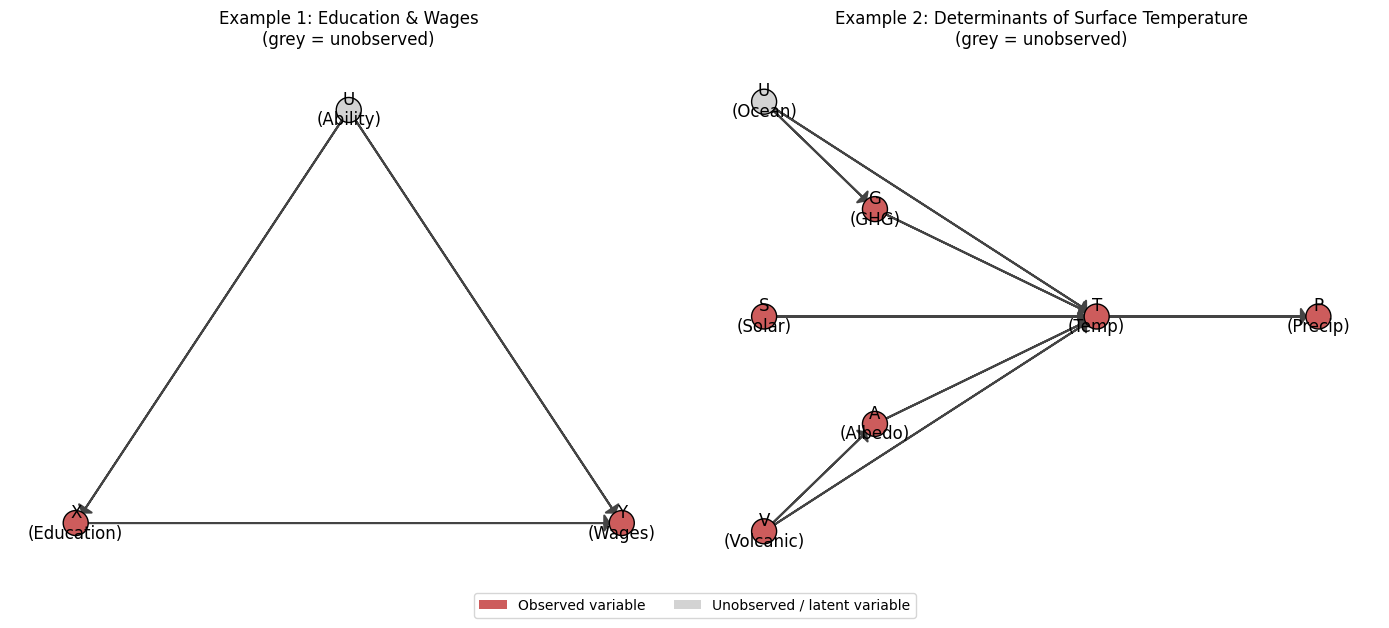

In [ ]:
# ── Example 1: Education, Wages, Ability ──────────────────────────────────────
# Nodes: U = Ability (unobserved), X = Education, Y = Wages
# Edges: U -> X, U -> Y, X -> Y
dag1 = ig.Graph(directed=True)
dag1.add_vertices(3)
dag1.add_edges([(0, 1), (0, 2), (1, 2)])   # U->X, U->Y, X->Y
dag1.vs["unobserved"] = [True, False, False]
dag1_layout = [(1, 1), (0, 0), (2, 0)]  # U top-center, X bottom-left, Y bottom-right
dag1_labels = ["U\n(Ability)", "X\n(Education)", "Y\n(Wages)"]
dag1_colors = ["lightgrey" if dag1.vs[i]["unobserved"] else "indianred" for i in range(dag1.vcount())]

print("DAG 1 — Is DAG:", dag1.is_dag())
print("Topological order:", [dag1_labels[i].split()[0] for i in dag1.topological_sorting()])

# ── Example 2: Determinants of Surface Temperature T ─────────────────────────
# Nodes:
#   S  = Solar Irradiance (observed)
#   G  = Greenhouse Gas Concentration (observed)
#   A  = Albedo / Reflectivity (observed)
#   V  = Volcanic Aerosols (observed)
#   U  = Ocean Heat Content (unobserved — hard to measure globally)
#   T  = Surface Temperature (observed, outcome)
#   P  = Precipitation (observed, downstream effect)
# Edges:
#   S -> T  (more solar radiation increases temperature)
#   G -> T  (higher greenhouse gases trap heat)
#   A -> T  (higher albedo reflects more radiation, lowers T)
#   V -> A  (volcanic aerosols increase atmospheric reflectivity)
#   V -> T  (aerosols also directly cool surface)
#   U -> T  (ocean heat release warms surface)
#   U -> G  (ocean acts as CO2 sink/source, affecting GHG concentration)
#   T -> P  (higher temperature increases evaporation and precipitation)
dag2 = ig.Graph(directed=True)
dag2.add_vertices(7)
dag2.add_edges([
    (0, 5),   # S  -> T
    (1, 5),   # G  -> T
    (2, 5),   # A  -> T
    (3, 2),   # V  -> A
    (3, 5),   # V  -> T
    (4, 5),   # U  -> T
    (4, 1),   # U  -> G
    (5, 6),   # T  -> P
])
dag2.vs["unobserved"] = [False, False, False, False, True, False, False]

dag2_labels = ["S\n(Solar)", "G\n(GHG)", "A\n(Albedo)",
                "V\n(Volcanic)", "U\n(Ocean)", "T\n(Temp)", "P\n(Precip)"]
dag2_colors = ["lightgrey" if dag2.vs[i]["unobserved"] else "indianred" for i in range(dag2.vcount())]

# Manual layout: causes on left/top, T center-right, P far right
dag2_layout = [
    (0, 2),    # S
    (1, 3),    # G
    (1, 1),    # A
    (0, 0),    # V
    (0, 4),    # U
    (3, 2),    # T
    (5, 2),    # P
]

print("\nDAG 2 — Is DAG:", dag2.is_dag())
print("Topological order:", [dag2_labels[i].split()[0] for i in dag2.topological_sorting()])

# ── Plot side by side ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_graph(dag1, title="Example 1: Education & Wages\n(grey = unobserved)", ax=axes[0],
           labels=dag1_labels, layout=dag1_layout, colors=dag1_colors, show=False)
plot_graph(dag2, title="Example 2: Determinants of Surface Temperature\n(grey = unobserved)", ax=axes[1],
           labels=dag2_labels, layout=dag2_layout, colors=dag2_colors, show=False)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="indianred", label="Observed variable"),
    Patch(facecolor="lightgrey", label="Unobserved / latent variable"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=2,
           bbox_to_anchor=(0.5, -0.05), framealpha=0.8)

plt.tight_layout()
plt.show()